In [4]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [15]:
# -------------------- LOAD DATA --------------------
df = pd.read_csv("Ice_cream selling data.csv")   # change filename

print(df.head())
print(df.info())
print(df.isnull().sum())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes
None
Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64


In [7]:
# -------------------- LOAD DATA --------------------
df = pd.read_csv("Ice_cream selling data.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes
None
Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64


In [8]:
# -------------------- FEATURES & TARGET --------------------
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [9]:
# -------------------- TRAIN TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# -------------------- TRY DIFFERENT DEGREES --------------------
degrees = [1, 2, 3, 4]

for degree in degrees:

    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    print(f"\nDegree {degree}")
    print("R2 Score:", r2)
    print("RMSE:", rmse)


Degree 1
R2 Score: -0.5751270190188227
RMSE: 12.219913714640208

Degree 2
R2 Score: 0.8430551371938843
RMSE: 3.8573042971719858

Degree 3
R2 Score: 0.8405107685716914
RMSE: 3.8884456343415033

Degree 4
R2 Score: 0.8054468908427668
RMSE: 4.2946664206252


In [11]:
# -------------------- FINAL MODEL (Choose Best Degree) --------------------
best_degree = 3

model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree)),
    ('linear', LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('poly', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [12]:
# -------------------- FINAL PREDICTIONS --------------------
y_pred = model.predict(X_test)

print("\nFinal Model Degree:", best_degree)
print("Final R2 Score:", r2_score(y_test, y_pred))


Final Model Degree: 3
Final R2 Score: 0.8405107685716914


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


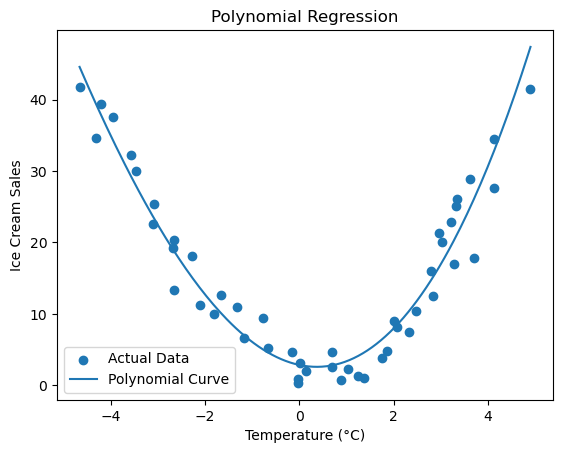

In [13]:
# -------------------- VISUALIZATION --------------------
X_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)

y_curve = model.predict(X_range)

plt.scatter(X, y, label="Actual Data")
plt.plot(X_range, y_curve, label="Polynomial Curve")

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.title("Polynomial Regression")
plt.legend()
plt.show()


In [14]:
# -------------------- USER INPUT --------------------
temp = float(input("Enter Temperature: "))

input_df = pd.DataFrame({
    'Temperature (°C)': [temp]
})

prediction = model.predict(input_df)

print("Predicted Ice Cream Sales:", round(prediction[0], 2))

Enter Temperature:  23


Predicted Ice Cream Sales: 1625.83
